In [1]:
import math 
import random 
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset 

torch.manual_seed(23)
np.random.seed(23)
random.seed(23)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
def load_mnist():
    # First try torchvision.
    try:
        from torchvision import datasets, transforms

        root = Path("./data")
        transform = transforms.ToTensor()

        train_ds = datasets.MNIST(root=root, train=True, download=True, transform=transform)
        test_ds = datasets.MNIST(root=root, train=False, download=True, transform=transform)

        X_train = train_ds.data.float() / 255.0
        y_train = train_ds.targets.long()
        X_test = test_ds.data.float() / 255.0
        y_test = test_ds.targets.long()

        source = "torchvision.datasets.MNIST"
        return X_train, y_train, X_test, y_test, source

    except Exception as e:
        print("torchvision load failed:", repr(e))
        print("  Falling back to sklearn.fetch_openml('mnist_784').")

    # Fallback: OpenML
    from sklearn.datasets import fetch_openml

    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X = mnist["data"].astype(np.float32) / 255.0
    y = mnist["target"].astype(np.int64)
    # OpenML version 1 of MNIST follows the standard 60k/10k split.

    X_train = torch.from_numpy(X[:60000]).view(-1, 28, 28)
    y_train = torch.from_numpy(y[:60000]).long()
    X_test = torch.from_numpy(X[60000:]).view(-1, 28, 28)
    y_test = torch.from_numpy(y[60000:]).long()

    source = "sklearn.fetch_openml('mnist_784')"
    return X_train, y_train, X_test, y_test, source

In [3]:
TRAIN_LIMIT = None
TEST_LIMIT = None

X_train_img, y_train, X_test_img, y_test, mnist_source = load_mnist()
print("Loaded from:", mnist_source)
print("Train images:", tuple(X_train_img.shape), "Train labels:", tuple(y_train.shape))
print("Test images :", tuple(X_test_img.shape), "Test labels:", tuple(y_test.shape))

if TRAIN_LIMIT is not None:
    X_train_img = X_train_img[:TRAIN_LIMIT]
    y_train = y_train[:TRAIN_LIMIT]

if TEST_LIMIT is not None:
    X_test_img = X_test_img[:TEST_LIMIT]
    y_test = y_test[:TEST_LIMIT]

print("\nAfter optional limiting:")
print("Train images:", tuple(X_train_img.shape), "Train labels:", tuple(y_train.shape))
print("Test images:", tuple(X_test_img.shape), "Test labels:", tuple(y_test.shape))

torchvision load failed: ModuleNotFoundError("No module named 'torchvision'")
  Falling back to sklearn.fetch_openml('mnist_784').
Loaded from: sklearn.fetch_openml('mnist_784')
Train images: (60000, 28, 28) Train labels: (60000,)
Test images : (10000, 28, 28) Test labels: (10000,)

After optional limiting:
Train images: (60000, 28, 28) Train labels: (60000,)
Test images: (10000, 28, 28) Test labels: (10000,)


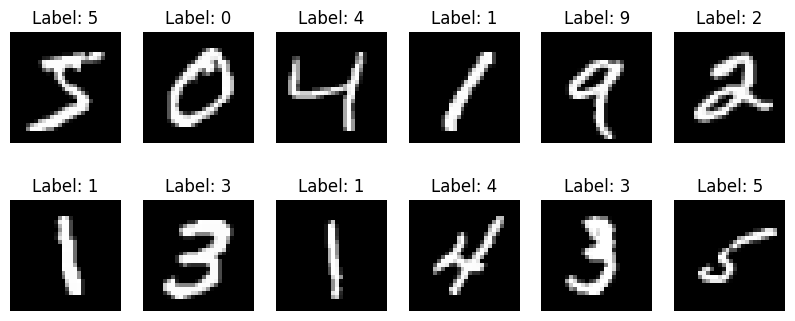

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), range(12)):
    ax.imshow(X_train_img[idx], cmap="gray")
    ax.set_title(f"Label: {y_train[idx]}")
    ax.axis("off")

In [5]:
BATCH_SIZE = 128

# Flatten images to vectors of length 784.
X_train_flat = X_train_img.view(len(X_train_img), -1)
X_test_flat = X_test_img.view(len(X_test_img), -1)

train_clf_ds = TensorDataset(X_train_flat, y_train)
test_clf_ds = TensorDataset(X_test_flat, y_test)

train_clf_loader = DataLoader(train_clf_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_clf_loader = DataLoader(test_clf_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_clf_loader))
print("One minibatch of inputs:", xb.shape)
print("One minibatch of labels:", yb.shape)

One minibatch of inputs: torch.Size([128, 784])
One minibatch of labels: torch.Size([128])


In [6]:
class MNISTFeedForward(nn.Module):
    def __init__(self, input_dim=28*28, hidden_dim=75, num_classes=10):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU()
        self.output = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        h = self.hidden(x)
        h = self.act(h)
        logits = self.output(h)
        return logits

clf_model = MNISTFeedForward().to(device)
clf_model

MNISTFeedForward(
  (hidden): Linear(in_features=784, out_features=75, bias=True)
  (act): ReLU()
  (output): Linear(in_features=75, out_features=10, bias=True)
)

In [7]:
xb, yb = next(iter(train_clf_loader))
xb = xb.to(device)

with torch.no_grad():
    h_pre = clf_model.hidden(xb)
    h = clf_model.act(h_pre)
    logits = clf_model.output(h)

print("Input shape:", tuple(xb.shape))
print("After Hidden Linear:", tuple(h.shape))
print("After ReLU:", tuple(h.shape))
print("After Output Linear:", tuple(logits.shape))
print("example logits:", logits[0].cpu().numpy())

Input shape: (128, 784)
After Hidden Linear: (128, 75)
After ReLU: (128, 75)
After Output Linear: (128, 10)
example logits: [ 0.05691883  0.09599999 -0.14498267  0.09250608 -0.05744721  0.07892962
 -0.02144349 -0.10305787  0.02141397  0.16649477]


In [8]:
def run_classifier_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = F.cross_entropy(logits, yb)

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_examples += xb.size(0)

    return total_loss / total_examples, total_correct / total_examples


def train_classifier(model, train_loader, test_loader, epochs=5, lr=1e-3):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    #optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_classifier_epoch(model, train_loader, optimizer)
        test_loss, test_acc = run_classifier_epoch(model, test_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch:3d}/{epochs} | "
            f"Train loss {train_loss:.4f}  acc {train_acc:.4f} | "
            f"Test loss {test_loss:.4f}  acc {test_acc:.4f}"
        )

    return history

In [9]:
clf_model = MNISTFeedForward().to(device)
history = train_classifier(clf_model, train_clf_loader, test_clf_loader, epochs=50, lr=1e-3)

Epoch   1/50 | Train loss 2.2624  acc 0.2094 | Test loss 2.2229  acc 0.3348
Epoch   2/50 | Train loss 2.1826  acc 0.4490 | Test loss 2.1327  acc 0.5359
Epoch   3/50 | Train loss 2.0855  acc 0.5905 | Test loss 2.0236  acc 0.6413
Epoch   4/50 | Train loss 1.9686  acc 0.6681 | Test loss 1.8935  acc 0.6975
Epoch   5/50 | Train loss 1.8322  acc 0.7092 | Test loss 1.7468  acc 0.7254
Epoch   6/50 | Train loss 1.6840  acc 0.7292 | Test loss 1.5931  acc 0.7411
Epoch   7/50 | Train loss 1.5334  acc 0.7441 | Test loss 1.4425  acc 0.7591
Epoch   8/50 | Train loss 1.3899  acc 0.7592 | Test loss 1.3035  acc 0.7747
Epoch   9/50 | Train loss 1.2603  acc 0.7748 | Test loss 1.1811  acc 0.7922
Epoch  10/50 | Train loss 1.1477  acc 0.7885 | Test loss 1.0764  acc 0.8057
Epoch  11/50 | Train loss 1.0521  acc 0.8014 | Test loss 0.9883  acc 0.8159
Epoch  12/50 | Train loss 0.9716  acc 0.8119 | Test loss 0.9143  acc 0.8259
Epoch  13/50 | Train loss 0.9039  acc 0.8209 | Test loss 0.8519  acc 0.8321
Epoch  14/50

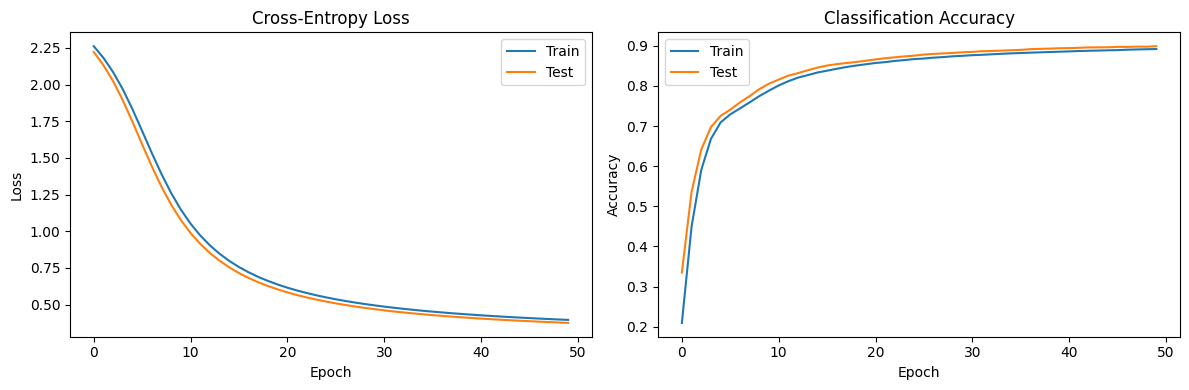

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["test_loss"], label="Test")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Cross-Entropy Loss")
ax1.legend()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["test_acc"], label="Test")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Classification Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()